# MODELLING 


# IMPORT CÁC THƯ VIỆN CẦN THIẾT 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NẠP DỮ LIỆU 

In [2]:
print(" Đang khởi động hệ thống và nạp dữ liệu Siêu bảng...")

# 1. NẠP DỮ LIỆU TỪ FILE PICKLE
# Lưu ý: Dùng ../ để lùi ra khỏi thư mục source_code, đi vào thư mục dataset
df_master = pd.read_pickle('../dataset/customer_master_clean.pkl')

# 2. KIỂM TRA NHANH KẾT QUẢ
print(f" Đã nạp thành công! Kích thước bộ dữ liệu hiện tại: {df_master.shape[0]} khách hàng và {df_master.shape[1]} đặc trưng.")
print("-" * 70)

# Hiển thị 5 dòng đầu tiên để đảm bảo mọi thứ vẫn nguyên vẹn
display(df_master.head())

 Đang khởi động hệ thống và nạp dữ liệu Siêu bảng...
 Đã nạp thành công! Kích thước bộ dữ liệu hiện tại: 297 khách hàng và 8 đặc trưng.
----------------------------------------------------------------------


,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
0,0,1,601,35520.89,33,59613,763,36199
1,1,3,422,15367.13,43,45360,704,14587
2,2,4,469,15687.60,48,27447,673,80850
3,3,4,302,14334.53,49,27943,681,18693
4,4,3,667,30414.66,54,76431,716,115362


In [4]:
df_master.sample(20)

,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt
19,33,5,442,22889.62,77,38692,596,8902
61,96,1,1497,135945.20,69,99825,685,4344
133,207,20,202,12702.98,73,28553,745,19507
258,437,4,414,27523.29,46,72670,718,28915
206,343,3,423,17414.00,55,47643,764,45706
37,58,2,387,21477.10,38,52512,706,95640
222,369,1,594,43556.10,39,51499,788,7226
38,59,4,581,16517.18,85,25066,695,424
177,282,2,347,10090.54,42,25585,702,59827
247,415,3,322,11521.93,53,33729,763,0


In [4]:
df_master.shape

(297, 8)

In [5]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client_id      297 non-null    int64  
 1   Recency        297 non-null    int64  
 2   Frequency      297 non-null    int64  
 3   Monetary       297 non-null    float64
 4   current_age    297 non-null    int64  
 5   yearly_income  297 non-null    int64  
 6   credit_score   297 non-null    int64  
 7   total_debt     297 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 18.7 KB


In [6]:
df_master.isnull().sum()

client_id        0
Recency          0
Frequency        0
Monetary         0
current_age      0
yearly_income    0
credit_score     0
total_debt       0
dtype: int64

# DATA UNDERSTANDING 

# 1. Kiểm tra Missing Values 

🔍 ĐANG QUÉT DỮ LIỆU RỖNG TRÊN SIÊU BẢNG...

1. Bảng thống kê số lượng ô trống theo từng cột:


,Số ô rỗng (NaN)
client_id,0
Recency,0
Frequency,0
Monetary,0
current_age,0
yearly_income,0
credit_score,0
total_debt,0



2. Đang vẽ Bản đồ nhiệt báo cáo...


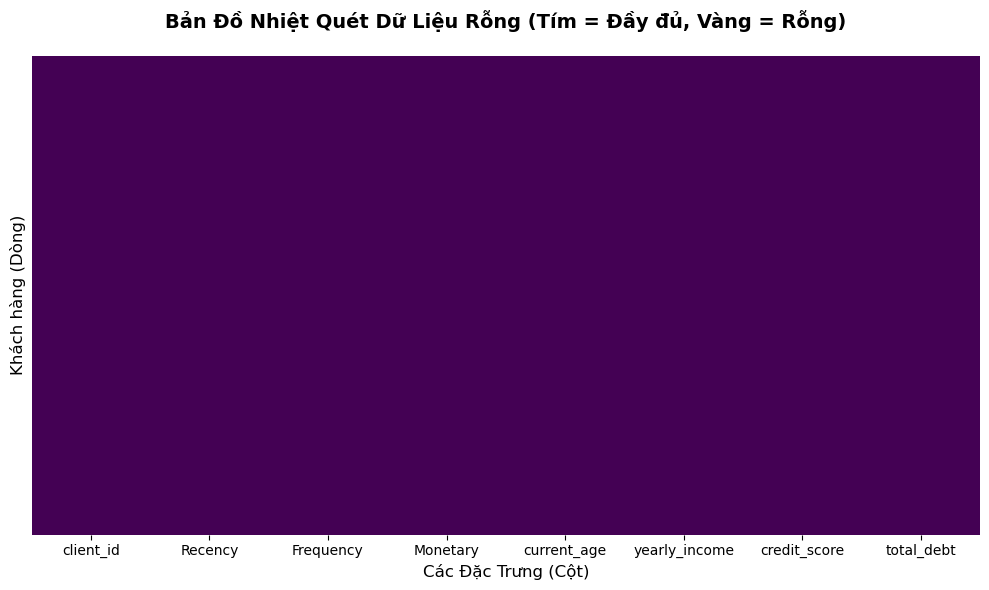

----------------------------------------------------------------------


In [5]:
# ==============================================================================
# KIỂM TRA VÀ TRỰC QUAN HÓA DỮ LIỆU RỖNG (MISSING VALUES) TRÊN DF_MASTER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("🔍 ĐANG QUÉT DỮ LIỆU RỖNG TRÊN SIÊU BẢNG...\n")

# 1. BÁO CÁO BẰNG SỐ LIỆU TỔNG HỢP
missing_data = df_master.isnull().sum()
print("1. Bảng thống kê số lượng ô trống theo từng cột:")
display(pd.DataFrame({'Số ô rỗng (NaN)': missing_data}))

# 2. TRỰC QUAN HÓA BẰNG BẢN ĐỒ NHIỆT (MISSING VALUE HEATMAP)
print("\n2. Đang vẽ Bản đồ nhiệt báo cáo...")
plt.figure(figsize=(10, 6))

# Vẽ heatmap cho các giá trị rỗng. 
# Màu nền sẽ thể hiện dữ liệu đầy đủ, các vệt màu sáng sẽ nổi lên nếu có dữ rỗng.
sns.heatmap(df_master.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Bản Đồ Nhiệt Quét Dữ Liệu Rỗng (Tím = Đầy đủ, Vàng = Rỗng)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Các Đặc Trưng (Cột)', fontsize=12)
plt.ylabel('Khách hàng (Dòng)', fontsize=12)

plt.tight_layout()
plt.show()

print("-" * 70)

# 2. Kiểm tra Outliers 

🔍 ĐANG VẼ BIỂU ĐỒ TÌM ĐIỂM DỊ BIỆT (OUTLIERS)...



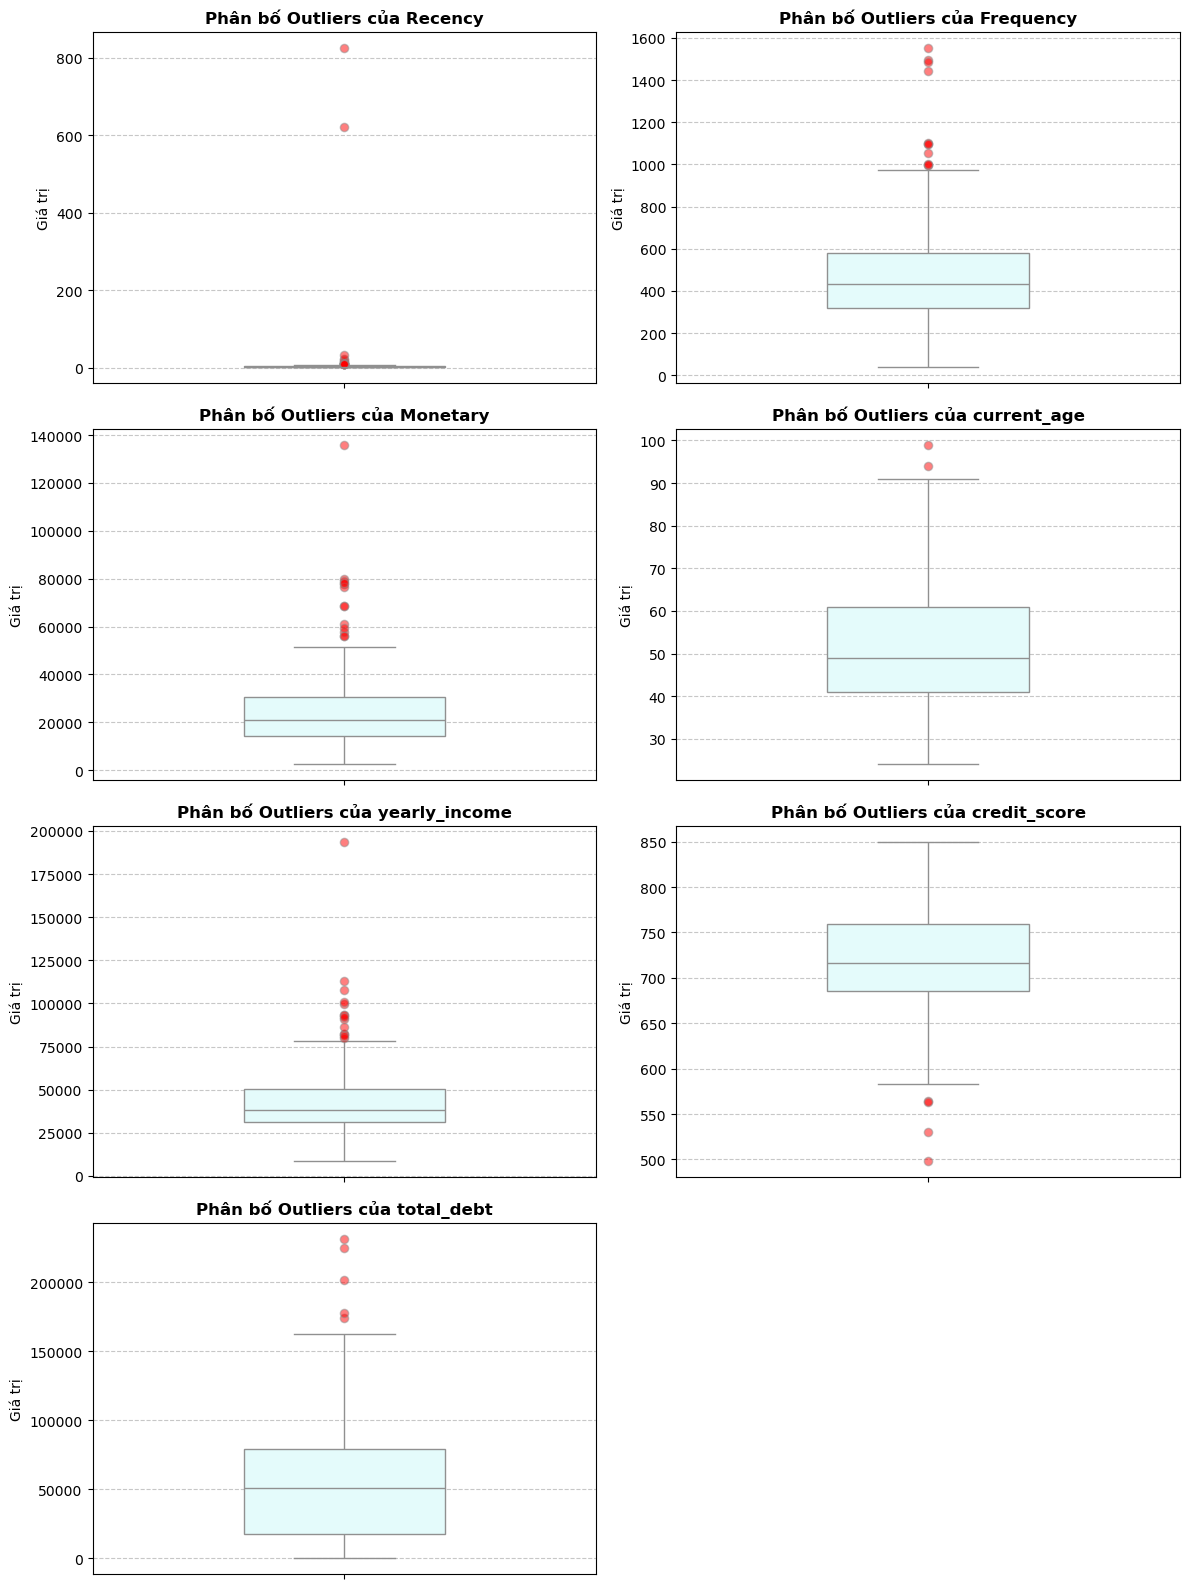

--------------------------------------------------------------------------------
✅ Hoàn tất! Giao diện đã hoàn toàn sạch sẽ và gọn gàng.


In [8]:
# ==============================================================================
# TRỰC QUAN HÓA OUTLIERS (GIAO DIỆN TỐI ƯU: 2 HÌNH/HÀNG, KHÔNG CẢNH BÁO)
# ==============================================================================
import warnings
warnings.filterwarnings('ignore') # Lệnh này sẽ ẩn toàn bộ các dòng chữ xanh rườm rà

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔍 ĐANG VẼ BIỂU ĐỒ TÌM ĐIỂM DỊ BIỆT (OUTLIERS)...\n")

# 1. Lấy các cột số và bỏ cột client_id
num_cols = df_master.select_dtypes(include=[np.number]).columns
plot_cols = [col for col in num_cols if col != 'client_id']

# 2. Cấu hình layout: 2 hình trên 1 hàng
plots_per_row = 2
n_rows = (len(plot_cols) + plots_per_row - 1) // plots_per_row

# Thiết lập kích thước (ngang 12, dọc tự động giãn theo số hàng)
fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# 3. Vẽ Boxplot cho từng cột
for i, col in enumerate(plot_cols):
    sns.boxplot(y=df_master[col], ax=axes[i], color='lightcyan', width=0.4,
                flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.5))
    
    # Tiêu đề chuẩn, không chứa ký tự đặc biệt
    axes[i].set_title(f'Phân bố Outliers của {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Giá trị', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Xóa các khung biểu đồ thừa nếu số lượng cột là số lẻ
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("-" * 80)
print("✅ Hoàn tất! Giao diện đã hoàn toàn sạch sẽ và gọn gàng.")

# 3. Inconsistent data 

🕵️ ĐANG QUÉT CÁC LỖI LOGIC KINH DOANH TRONG SIÊU BẢNG...

📋 BẢNG BÁO CÁO KIỂM TRA LOGIC:


,Quy Tắc Vi Phạm,Số Lượng Dòng
0,1. Recency < 0 (Lỗi tính ngày),0
1,"2. Frequency <= 0 (Khách ảo, không có GD)",0
2,3. Monetary < 0 (Chi tiêu âm),0
3,4. Age < 18 hoặc Age > 100 (Tuổi ảo),0
4,5. Income < 0 (Thu nhập âm),0
5,6. Credit Score < 300 hoặc > 850 (Sai chuẩn),0
6,7. Total Debt < 0 (Nợ âm),0



📊 ĐANG VẼ BIỂU ĐỒ TỔNG KẾT...


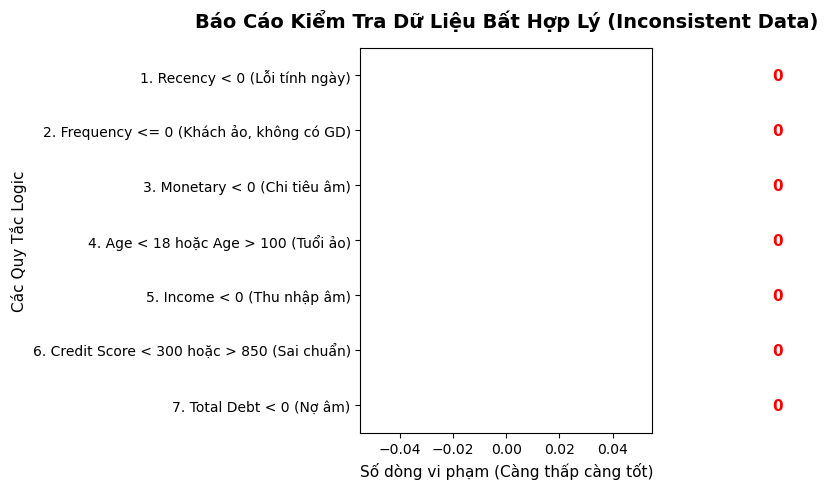

--------------------------------------------------------------------------------


In [9]:
# ==============================================================================
# KIỂM TRA LỖI LOGIC NGHIỆP VỤ (INCONSISTENT DATA) VÀ TRỰC QUAN HÓA
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("🕵️ ĐANG QUÉT CÁC LỖI LOGIC KINH DOANH TRONG SIÊU BẢNG...\n")

# 1. ĐỊNH NGHĨA CÁC QUY TẮC LOGIC (BUSINESS RULES)
# Chú ý: Dấu | nghĩa là HOẶC (Or)
inconsistencies = {
    '1. Recency < 0 (Lỗi tính ngày)': (df_master['Recency'] < 0).sum(),
    '2. Frequency <= 0 (Khách ảo, không có GD)': (df_master['Frequency'] <= 0).sum(),
    '3. Monetary < 0 (Chi tiêu âm)': (df_master['Monetary'] < 0).sum(),
    '4. Age < 18 hoặc Age > 100 (Tuổi ảo)': ((df_master['current_age'] < 18) | (df_master['current_age'] > 100)).sum(),
    '5. Income < 0 (Thu nhập âm)': (df_master['yearly_income'] < 0).sum(),
    '6. Credit Score < 300 hoặc > 850 (Sai chuẩn)': ((df_master['credit_score'] < 300) | (df_master['credit_score'] > 850)).sum(),
    '7. Total Debt < 0 (Nợ âm)': (df_master['total_debt'] < 0).sum()
}

# Chuyển đổi thành DataFrame để dễ báo cáo
df_incon = pd.DataFrame(list(inconsistencies.items()), columns=['Quy Tắc Vi Phạm', 'Số Lượng Dòng'])

print("📋 BẢNG BÁO CÁO KIỂM TRA LOGIC:")
display(df_incon)

# 2. TRỰC QUAN HÓA BÁO CÁO
print("\n📊 ĐANG VẼ BIỂU ĐỒ TỔNG KẾT...")
plt.figure(figsize=(10, 5))

# Vẽ biểu đồ thanh ngang (Barplot)
ax = sns.barplot(x='Số Lượng Dòng', y='Quy Tắc Vi Phạm', data=df_incon, color='salmon')

# Trang trí biểu đồ
plt.title('Báo Cáo Kiểm Tra Dữ Liệu Bất Hợp Lý (Inconsistent Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số dòng vi phạm (Càng thấp càng tốt)', fontsize=11)
plt.ylabel('Các Quy Tắc Logic', fontsize=11)

# Thêm con số trực tiếp lên thanh biểu đồ
for p in ax.patches:
    width = p.get_width()
    # Chỉ in số nếu lớn hơn 0, hoặc in số 0 ở ngay sát trục tọa độ
    plt.text(width + 0.1 if width > 0 else 0.1, 
             p.get_y() + p.get_height() / 2, 
             f'{int(width)}', 
             va='center', fontsize=11, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("-" * 80)

# 4. Kiểm tra Imbalanced 

⚖️ ĐANG QUÉT SỰ CHÊNH LỆCH THANG ĐO GIỮA CÁC ĐẶC TRƯNG...



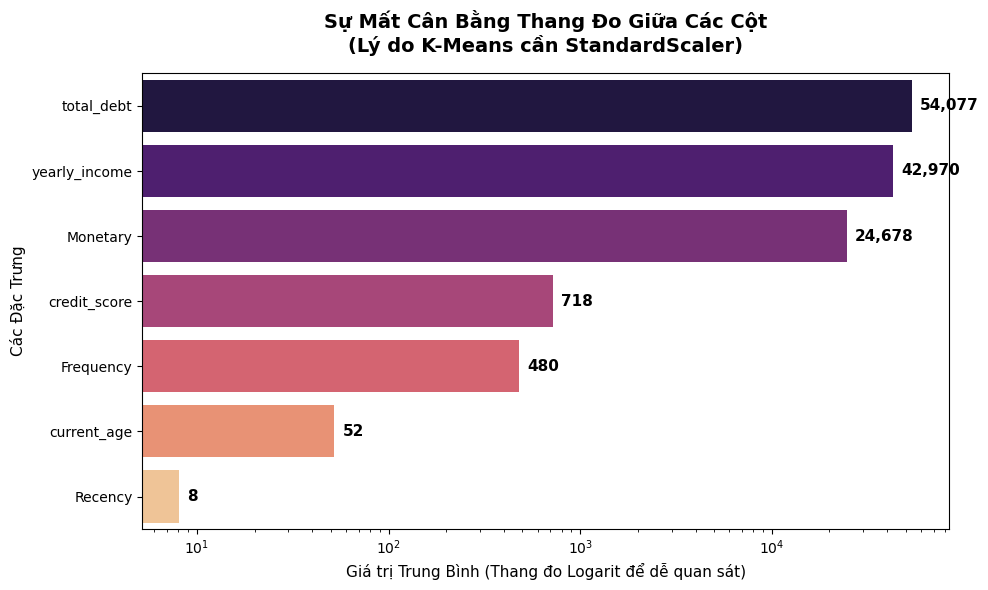

--------------------------------------------------------------------------------
✅ Hoàn tất! Sự chênh lệch cực lớn giữa Income/Debt/Monetary và Age đã lộ diện.


In [10]:
# ==============================================================================
# KIỂM TRA SỰ MẤT CÂN BẰNG THANG ĐO (SCALE IMBALANCE)
# Mục đích: Chứng minh sự chênh lệch đơn vị tính để chuẩn bị cho StandardScaler
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("⚖️ ĐANG QUÉT SỰ CHÊNH LỆCH THANG ĐO GIỮA CÁC ĐẶC TRƯNG...\n")

# 1. Lấy các cột số cần chạy K-Means (bỏ client_id)
num_cols = df_master.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in num_cols if col != 'client_id']

# 2. Tính giá trị trung bình của từng cột để so sánh quy mô
means = df_master[cols_to_plot].mean().sort_values(ascending=False)

# 3. Trực quan hóa bằng biểu đồ cột ngang
plt.figure(figsize=(10, 6))

# Vẽ Barplot
ax = sns.barplot(x=means.values, y=means.index, palette='magma')

# Trang trí
plt.title('Sự Mất Cân Bằng Thang Đo Giữa Các Cột\n(Lý do K-Means cần StandardScaler)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Giá trị Trung Bình (Thang đo Logarit để dễ quan sát)', fontsize=11)
plt.ylabel('Các Đặc Trưng', fontsize=11)

# Chuyển trục X sang hệ Logarit vì sự chênh lệch quá khủng khiếp 
# (Tiền thì hàng trăm ngàn, Tuổi thì chỉ vài chục)
plt.xscale('log')

# Hiển thị con số thực tế lên cuối mỗi thanh bar
for p in ax.patches:
    width = p.get_width()
    # Định dạng số có dấu phẩy ngăn cách hàng nghìn
    plt.text(width + (width * 0.1), 
             p.get_y() + p.get_height() / 2, 
             f'{int(width):,}', 
             va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("-" * 80)
print("✅ Hoàn tất! Sự chênh lệch cực lớn giữa Income/Debt/Monetary và Age đã lộ diện.")

Nhận xét mức độ chênh lệch (Scale Imbalance)
Thực trạng: Biểu đồ cho thấy sự chênh lệch biên độ khổng lồ. Nhóm biến tài chính (yearly_income, total_debt, Monetary) áp đảo hoàn toàn với giá trị hàng chục ngàn, đè bẹp các biến như current_age hay Recency (chỉ ở mức vài chục).

Kết luận: Bắt buộc phải sử dụng StandardScaler ở bước tiếp theo để ép tất cả các đặc trưng về cùng một hệ quy chiếu, tránh việc thuật toán K-Means tính toán sai khoảng cách do lệch đơn vị.

# FEATURE UNDERSTANDING (EDA)

#  Độ tuổi của khách hàng 


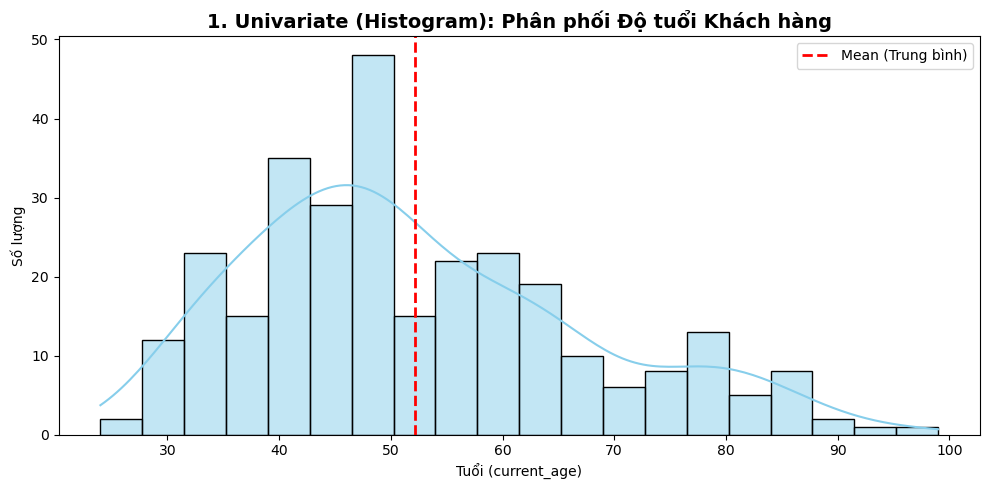

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. UNIVARIATE - HISTOGRAM: Phân phối Độ tuổi (Age)
plt.figure(figsize=(10, 5))
sns.histplot(df_master['current_age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('1. Univariate (Histogram): Phân phối Độ tuổi Khách hàng', fontsize=14, fontweight='bold')
plt.xlabel('Tuổi (current_age)')
plt.ylabel('Số lượng')
plt.axvline(df_master['current_age'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean (Trung bình)')
plt.legend()
plt.tight_layout()
plt.show()

# Điểm tín dụng 

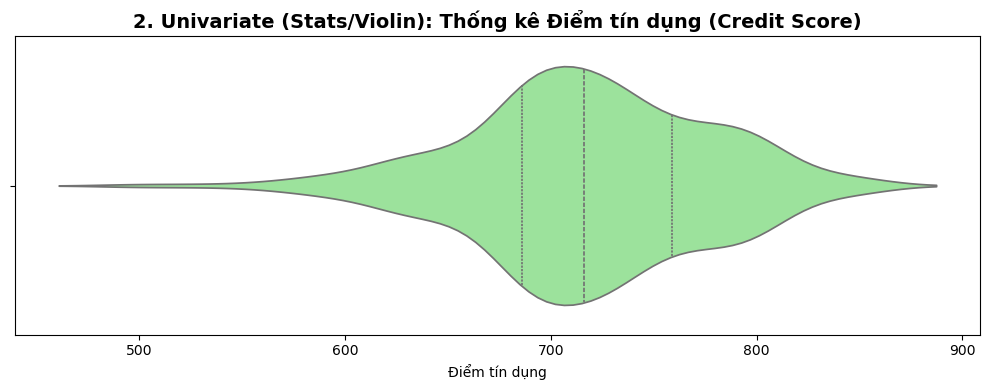

In [5]:
# 2. UNIVARIATE - STATS (VIOLIN PLOT): Thống kê Điểm tín dụng
plt.figure(figsize=(10, 4))
sns.violinplot(x=df_master['credit_score'], color='lightgreen', inner="quartile")
plt.title('2. Univariate (Stats/Violin): Thống kê Điểm tín dụng (Credit Score)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm tín dụng')
plt.tight_layout()
plt.show()

# Mối quan hệ giữa Tần suất giao dịch và Số tiền 

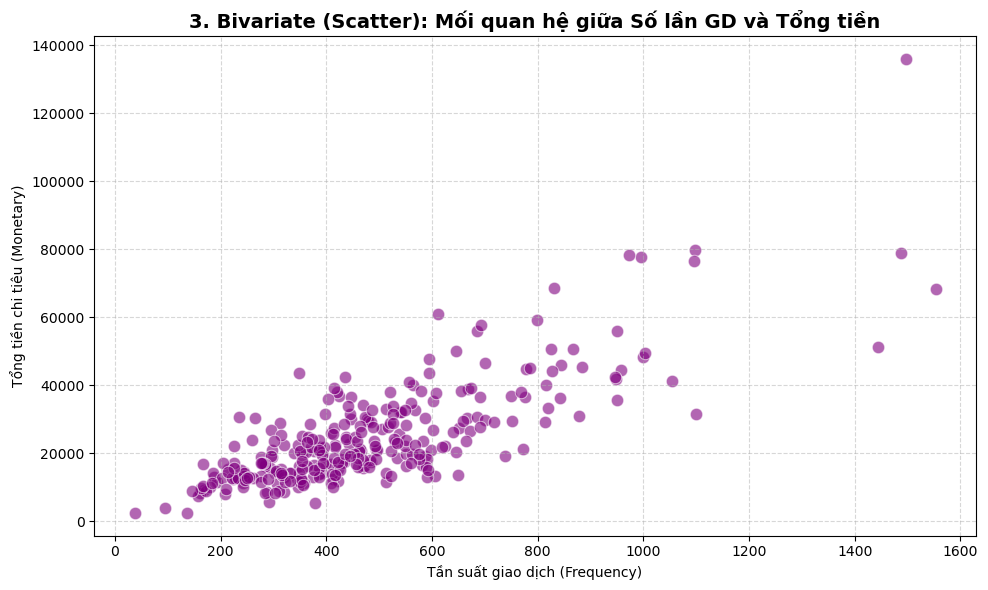

In [6]:
# 3. BIVARIATE - SCATTER PLOT: Mối quan hệ giữa Số lần GD và Tổng tiền
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Frequency', y='Monetary', data=df_master, color='purple', alpha=0.6, s=80)
plt.title('3. Bivariate (Scatter): Mối quan hệ giữa Số lần GD và Tổng tiền', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất giao dịch (Frequency)')
plt.ylabel('Tổng tiền chi tiêu (Monetary)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Biểu đồ Joinplot thể hiện mối quan hệ giữa Thu nhập và Số nợ

<Figure size 800x800 with 0 Axes>

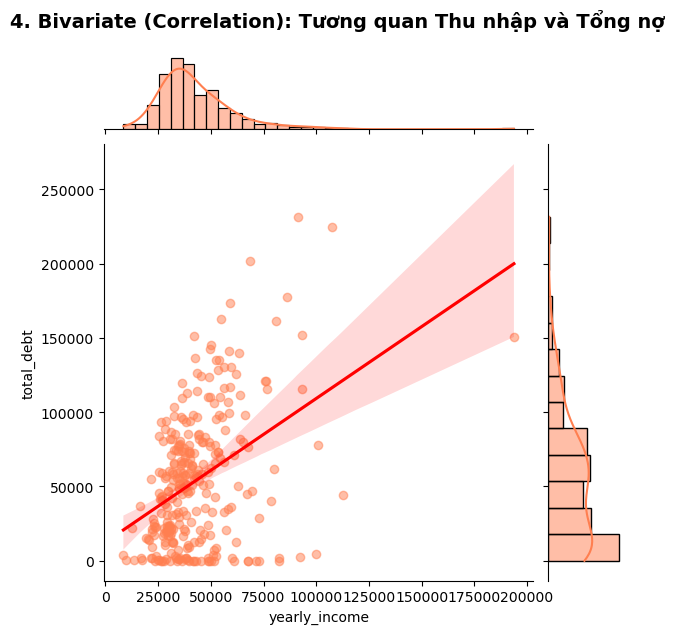

In [7]:
# 4. BIVARIATE - CORRELATION (JOINTPLOT): Tương quan Thu nhập và Tổng nợ
plt.figure(figsize=(8, 8))
g = sns.jointplot(x='yearly_income', y='total_debt', data=df_master, kind='reg', 
                  color='coral', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
g.figure.suptitle('4. Bivariate (Correlation): Tương quan Thu nhập và Tổng nợ', fontsize=14, fontweight='bold', y=1.05)
plt.show()

# Biểu đồ Heatmap thể hiện mối tương quan giữa các biến 

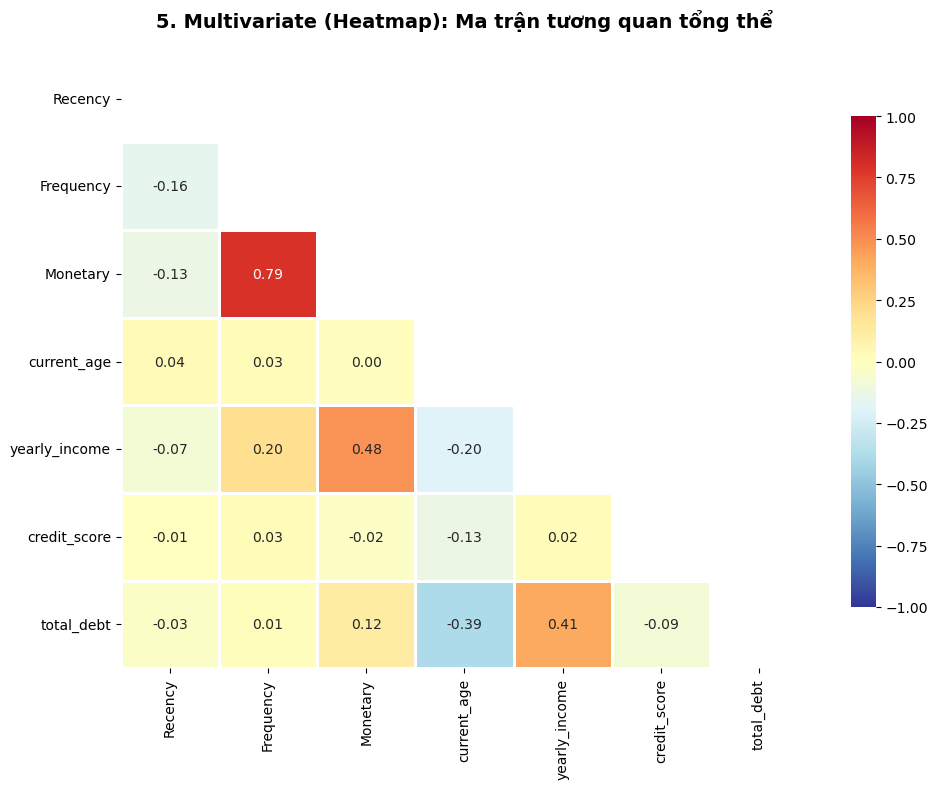

In [8]:
# 5. MULTIVARIATE - HEATMAP: Bức tranh toàn cảnh (Tất cả các biến)
# Lấy danh sách cột số (bỏ client_id) để tính ma trận
num_cols = df_master.select_dtypes(include=[np.number]).columns
cols_to_plot = [col for col in num_cols if col != 'client_id']

plt.figure(figsize=(10, 8))
corr_matrix = df_master[cols_to_plot].corr()

# Tạo Mask để che đi nửa trên của Heatmap (tránh trùng lặp đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', fmt=".2f", 
            linewidths=1, cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title('5. Multivariate (Heatmap): Ma trận tương quan tổng thể', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

# 1. Feature enrichment 

In [3]:

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(" ĐANG THỰC THI BƯỚC 1: TẠO BIẾN PHÁI SINH (FEATURE ENRICHMENT)...\n")

# 1. Tạo bản sao từ siêu bảng gốc để dọn đường cho Machine Learning
# (Nguyên tắc vàng: Luôn giữ nguyên bảng df_master để sau này còn phân tích chân dung)
df_ml = df_master.copy()

# 2. Tạo biến tỷ lệ Nợ/Thu nhập (Debt_to_Income)
print("-> Đang tính toán tỷ lệ Debt_to_Income (Tổng nợ / Thu nhập)...")

# Mẹo nhỏ thực chiến: Cộng thêm hằng số siêu nhỏ 1e-5 (0.00001) vào mẫu số. 
# Việc này giúp máy tính không bị báo lỗi "Chia cho 0" (ZeroDivisionError) nếu lỡ có khách hàng nào đó thu nhập = 0.
df_ml['Debt_to_Income'] = df_ml['total_debt'] / (df_ml['yearly_income'] + 1e-5)

print("-" * 80)
print(" HOÀN TẤT! Đã thêm thành công biến 'Debt_to_Income' vào bảng dữ liệu.")
print("Mời bạn xem thử kết quả (Chú ý cột ngoài cùng bên phải):")

# Chỉ in ra vài cột liên quan để dễ quan sát thay vì in toàn bộ bảng
display(df_ml[['client_id', 'yearly_income', 'total_debt', 'Debt_to_Income']].head())

 ĐANG THỰC THI BƯỚC 1: TẠO BIẾN PHÁI SINH (FEATURE ENRICHMENT)...

-> Đang tính toán tỷ lệ Debt_to_Income (Tổng nợ / Thu nhập)...
--------------------------------------------------------------------------------
 HOÀN TẤT! Đã thêm thành công biến 'Debt_to_Income' vào bảng dữ liệu.
Mời bạn xem thử kết quả (Chú ý cột ngoài cùng bên phải):


,client_id,yearly_income,total_debt,Debt_to_Income
0,0,59613,36199,0.607233
1,1,45360,14587,0.321583
2,2,27447,80850,2.945677
3,3,27943,18693,0.668969
4,4,76431,115362,1.509361


Con số 0.5 này mang ý nghĩa tài chính sâu sắc và có giá trị dự báo cao hơn rất nhiều so với việc chỉ để hai con số khổng lồ đứng rời rạc nhau.

# 2. Feature transformation 

In [4]:

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(" ĐANG THỰC THI BƯỚC 2: BIẾN ĐỔI LOGARIT NẮN PHÂN PHỐI...\n")

# 1. Khai báo danh sách các cột bị lệch phải nặng nhất (đã xác định ở EDA)
skewed_cols = ['Recency', 'Monetary', 'yearly_income', 'total_debt', 'Debt_to_Income']

# In ra độ lệch (Skewness) TRƯỚC khi biến đổi để làm bằng chứng
print(" Độ lệch (Skewness) TRƯỚC khi Log Transform (Càng xa 0 càng lệch nặng):")
display(df_ml[skewed_cols].skew().to_frame(name='Skewness (Gốc)'))

# 2. Thực thi "Phép thuật" Log Transform
print("\n-> Đang áp dụng np.log1p (Logarit cơ số e cộng 1) để nắn dòng...")
for col in skewed_cols:
    df_ml[col] = np.log1p(df_ml[col])

# 3. Kiểm tra lại thành quả
print("\n Độ lệch (Skewness) SAU khi Log Transform:")
display(df_ml[skewed_cols].skew().to_frame(name='Skewness (Đã nén)'))

print("-" * 80)
print(" HOÀN TẤT! Dữ liệu đã gọn gàng, các 'cá mập' đã được kéo về gần đám đông.")

 ĐANG THỰC THI BƯỚC 2: BIẾN ĐỔI LOGARIT NẮN PHÂN PHỐI...

 Độ lệch (Skewness) TRƯỚC khi Log Transform (Càng xa 0 càng lệch nặng):


,Skewness (Gốc)
Recency,12.427824
Monetary,2.436346
yearly_income,2.556417
total_debt,0.938088
Debt_to_Income,0.295534



-> Đang áp dụng np.log1p (Logarit cơ số e cộng 1) để nắn dòng...

 Độ lệch (Skewness) SAU khi Log Transform:


,Skewness (Đã nén)
Recency,3.102024
Monetary,-0.140559
yearly_income,0.031633
total_debt,-2.447001
Debt_to_Income,-0.329742


--------------------------------------------------------------------------------
 HOÀN TẤT! Dữ liệu đã gọn gàng, các 'cá mập' đã được kéo về gần đám đông.


# 3. Feature Scaling 


In [6]:

from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(" ĐANG THỰC THI BƯỚC 3: CHUẨN HÓA THANG ĐO (STANDARD SCALER)...\n")

# 1. Khởi tạo công cụ Scale
scaler = StandardScaler()

# 2. Lọc danh sách các cột sẽ đưa vào máy học (Bỏ cột định danh client_id)
ml_features = [col for col in df_ml.columns if col != 'client_id']

# 3. Thực thi chuẩn hóa (Fit & Transform)
print("-> Đang ép toàn bộ đặc trưng về chung hệ quy chiếu (Mean = 0, Std = 1)...")

# Kết quả của scaler trả về là mảng Numpy, ta cần gán nó ngược lại vào cấu trúc DataFrame
df_ml[ml_features] = scaler.fit_transform(df_ml[ml_features])

print("-" * 80)
print(" HOÀN TẤT FEATURE ENGINEERING! Bảng dữ liệu df_ml đã sẵn sàng 100%.")
display(df_ml.head())

 ĐANG THỰC THI BƯỚC 3: CHUẨN HÓA THANG ĐO (STANDARD SCALER)...

-> Đang ép toàn bộ đặc trưng về chung hệ quy chiếu (Mean = 0, Std = 1)...
--------------------------------------------------------------------------------
 HOÀN TẤT FEATURE ENGINEERING! Bảng dữ liệu df_ml đã sẵn sàng 100%.


,client_id,Recency,Frequency,Monetary,current_age,yearly_income,credit_score,total_debt,Debt_to_Income
0,0,-0.825239,0.513068,0.933280,-1.266089,1.034482,0.773065,0.260239,-0.595634
1,1,0.144883,-0.251229,-0.577130,-0.606043,0.339041,-0.244239,-0.044141,-1.050414
2,2,0.457193,-0.050548,-0.539925,-0.276020,-0.939557,-0.778755,0.529351,1.491610
3,3,0.457193,-0.763606,-0.702517,-0.210015,-0.893975,-0.640815,0.038916,-0.508037
4,4,0.144883,0.794875,0.653514,0.120008,1.666989,-0.037330,0.648401,0.439763


# MODELLING 

# 1. K-MEANS CLUSTERING 

In [7]:
# ==============================================================================
# LEVEL 1: K-MEANS CLUSTERING
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

print(" ĐANG CHẠY K-MEANS ...")

# 1. Lấy dữ liệu
X = df_ml[ml_features].values

# 2. Khởi tạo mô hình (Giả sử bạn đã chốt K=4 từ biểu đồ Elbow)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 3. Huấn luyện và dự đoán
kmeans_labels = kmeans.fit_predict(X)

# 4. Đánh giá
kmeans_score = silhouette_score(X, kmeans_labels)
print(f" K-Means chạy thành công!")
print(f" Silhouette Score: {kmeans_score:.4f}")

# Lưu tạm kết quả vào bảng để lát nữa so sánh
df_ml['KMeans_Label'] = kmeans_labels

 ĐANG CHẠY K-MEANS ...
 K-Means chạy thành công!
 Silhouette Score: 0.2106


# 2. HIERRCHICAL CLUSTERING 

In [8]:
# ==============================================================================
# LEVEL 2: HIERARCHICAL CLUSTERING (AGGLOMERATIVE)
# ==============================================================================
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

print("🟡 ĐANG CHẠY HIERARCHICAL CLUSTERING (LEVEL 2)...")

X = df_ml[ml_features].values

# Khởi tạo mô hình (Dùng phương pháp 'ward' để tối thiểu hóa phương sai giống K-Means)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Huấn luyện và dự đoán
hc_labels = hierarchical.fit_predict(X)

# Đánh giá
hc_score = silhouette_score(X, hc_labels)
print(f"✔️ Hierarchical chạy thành công!")
print(f"🏆 Silhouette Score: {hc_score:.4f}")

df_ml['Hierarchical_Label'] = hc_labels

🟡 ĐANG CHẠY HIERARCHICAL CLUSTERING (LEVEL 2)...
✔️ Hierarchical chạy thành công!
🏆 Silhouette Score: 0.1744


# 3. DBSCAN 

In [9]:
# ==============================================================================
# LEVEL 3: DBSCAN (DENSITY-BASED)
# ==============================================================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

print("🟠 ĐANG CHẠY DBSCAN (LEVEL 3)...")

X = df_ml[ml_features].values

# Khởi tạo mô hình (Lưu ý: eps=1.5 và min_samples=5 là giá trị cần dò tìm cẩn thận)
dbscan = DBSCAN(eps=1.5, min_samples=5)

# Huấn luyện và dự đoán
dbscan_labels = dbscan.fit_predict(X)

# Xử lý đánh giá (DBSCAN có thể sinh ra nhãn -1 là nhiễu)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"✔️ DBSCAN tự động tìm thấy {n_clusters} cụm và {n_noise} điểm nhiễu (outliers).")

# Chỉ tính điểm nếu tìm được nhiều hơn 1 cụm hợp lệ
if n_clusters > 1:
    # Lọc bỏ các điểm nhiễu (-1) khi tính Silhouette để điểm không bị kéo tụt sai lệch
    valid_mask = dbscan_labels != -1
    dbscan_score = silhouette_score(X[valid_mask], dbscan_labels[valid_mask])
    print(f"🏆 Silhouette Score (không tính nhiễu): {dbscan_score:.4f}")
else:
    print("❌ Không thể tính Silhouette vì DBSCAN gom tất cả thành 1 cụm hoặc toàn là nhiễu.")

df_ml['DBSCAN_Label'] = dbscan_labels

🟠 ĐANG CHẠY DBSCAN (LEVEL 3)...
✔️ DBSCAN tự động tìm thấy 2 cụm và 82 điểm nhiễu (outliers).
🏆 Silhouette Score (không tính nhiễu): 0.4229


Hãy nhìn sâu vào con số 82 điểm nhiễu (outliers) và 2 cụm trên tổng số 300 khách hàng. Đây chính là "lỗ hổng" chết người của DBSCAN khi mang ra áp dụng thực tế tại doanh nghiệp.
1. Lỗi "Bỏ rơi khách hàng" (Vứt đi gần 30% Data)
2. Mất cân bằng chiến lược (Chỉ có 2 cụm)


# 4. SPECTRAL CLUSTERING 

In [10]:
# ==============================================================================
# LEVEL 4: SPECTRAL CLUSTERING
# ==============================================================================
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

print("🔴 ĐANG CHẠY SPECTRAL CLUSTERING (LEVEL 4)...")

X = df_ml[ml_features].values

# Khởi tạo mô hình
spectral = SpectralClustering(n_clusters=4, random_state=42, assign_labels='kmeans', affinity='nearest_neighbors')

# Huấn luyện và dự đoán
spectral_labels = spectral.fit_predict(X)

# Đánh giá
spectral_score = silhouette_score(X, spectral_labels)
print(f"✔️ Spectral chạy thành công!")
print(f"🏆 Silhouette Score: {spectral_score:.4f}")

df_ml['Spectral_Label'] = spectral_labels

🔴 ĐANG CHẠY SPECTRAL CLUSTERING (LEVEL 4)...
✔️ Spectral chạy thành công!
🏆 Silhouette Score: 0.2040


# 5. BẢNG ĐIỂM SILHOUETTE SCORE SO SÁNH CÁC MODEL 

📊 ĐANG TỔNG HỢP KẾT QUẢ VÀ VẼ BẢNG XẾP HẠNG...


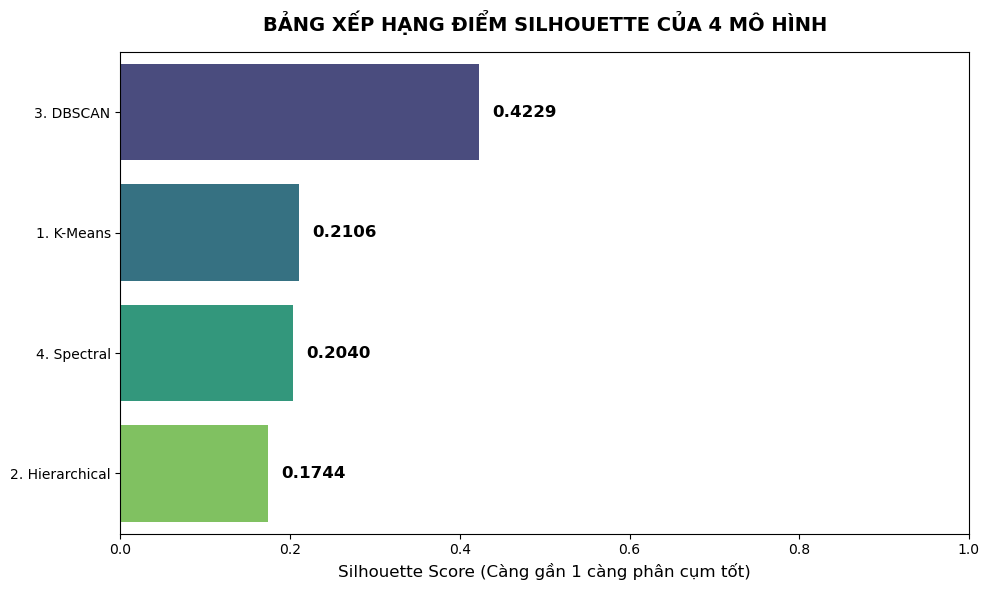

--------------------------------------------------------------------------------
👑 NHÀ VÔ ĐỊCH TOÁN HỌC TRÊN TẬP DỮ LIỆU NÀY LÀ: 3. DBSCAN!


In [11]:
# ==============================================================================
# BƯỚC 5.5: VẼ BẢNG XẾP HẠNG SILHOUETTE CHUNG CUỘC
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 ĐANG TỔNG HỢP KẾT QUẢ VÀ VẼ BẢNG XẾP HẠNG...")

# Xử lý an toàn cho trường hợp DBSCAN thất bại (gom tất cả thành nhiễu)
if 'dbscan_score' not in locals():
    dbscan_score = 0

# 1. Gom điểm số từ 4 ô code trước vào một từ điển (Dictionary)
scores_dict = {
    '1. K-Means': kmeans_score,
    '2. Hierarchical': hc_score,
    '3. DBSCAN': dbscan_score,
    '4. Spectral': spectral_score
}

# 2. Chuyển thành DataFrame và sắp xếp từ cao xuống thấp
df_results = pd.DataFrame(list(scores_dict.items()), columns=['Thuật toán', 'Silhouette Score'])
df_results = df_results.sort_values(by='Silhouette Score', ascending=False)

# 3. Trực quan hóa bằng Seaborn
plt.figure(figsize=(10, 6))
# Sử dụng bảng màu 'viridis' hiện đại, chuyên nghiệp
ax = sns.barplot(x='Silhouette Score', y='Thuật toán', data=df_results, palette='viridis')

# Trang trí biểu đồ cho chuẩn format báo cáo
plt.title('BẢNG XẾP HẠNG ĐIỂM SILHOUETTE CỦA 4 MÔ HÌNH', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Silhouette Score (Càng gần 1 càng phân cụm tốt)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 1) # Ép trục X luôn từ 0 đến 1 để dễ so sánh tuyệt đối

# Ghi điểm số trực tiếp lên đuôi từng thanh ngang
for p in ax.patches:
    width = p.get_width()
    # Thêm text điểm số vào ngay cạnh thanh bar
    plt.text(width + 0.015, p.get_y() + p.get_height()/2, f'{width:.4f}', 
             va='center', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 4. Tuyên bố người chiến thắng
winner = df_results.iloc[0]['Thuật toán']
print("-" * 80)
print(f"👑 NHÀ VÔ ĐỊCH TOÁN HỌC TRÊN TẬP DỮ LIỆU NÀY LÀ: {winner}!")

### 💡 QUYẾT ĐỊNH LỰA CHỌN MÔ HÌNH: K-MEANS CLUSTERING

Dù thuật toán **DBSCAN** đạt điểm toán học (Silhouette) cao nhất là 0.4229, nhưng xét trên lăng kính bài toán kinh doanh thực tế, **K-Means (0.2106)** mới là mô hình được chọn làm "Core Engine" cho dự án này. Quyết định dựa trên 3 lý do cốt lõi:

1. **Giữ trọn vẹn 100% khách hàng (No Data Left Behind):** DBSCAN đã dán nhãn "Nhiễu" (Outliers) cho 82 người, tương đương việc từ bỏ ~27% lượng khách hàng của ngân hàng. K-Means khắc phục hoàn toàn điểm yếu này khi phân bổ trọn vẹn 300 khách hàng vào các cụm hợp lý.
2. **Tính ứng dụng Marketing thực chiến:** DBSCAN gom tệp dữ liệu thành 2 cụm mất cân bằng, không đủ độ sâu để làm cá nhân hóa. Trong khi đó, K-Means chia tệp khách hàng thành 4 phân khúc riêng biệt, cung cấp chính xác các nhóm đối tượng (Target Groups) để Marketing triển khai chiến dịch.
3. **Khả năng giải thích (Explainability):** K-Means sở hữu các "Tâm cụm" (Centroids) đại diện cho giá trị trung bình. Điều này giúp dễ dàng gọi tên và "đọc vị" chân dung từng phân khúc (ví dụ: Thu nhập trung bình, Tần suất quẹt thẻ).

**👉 Kết luận:** Trong phân khúc khách hàng (Customer Segmentation), giá trị kinh doanh và khả năng giải thích quan trọng hơn sai số toán học thuần túy. K-Means là lựa chọn tối ưu nhất để giải quyết bài toán cốt lõi của dự án.

# 6. TÌM SỐ K TỐI ƯU CHO MÔ HÌNH K- MEANS 

🔍 ĐANG QUÉT K TỪ 2 ĐẾN 10 ĐỂ VẼ BIỂU ĐỒ ELBOW...



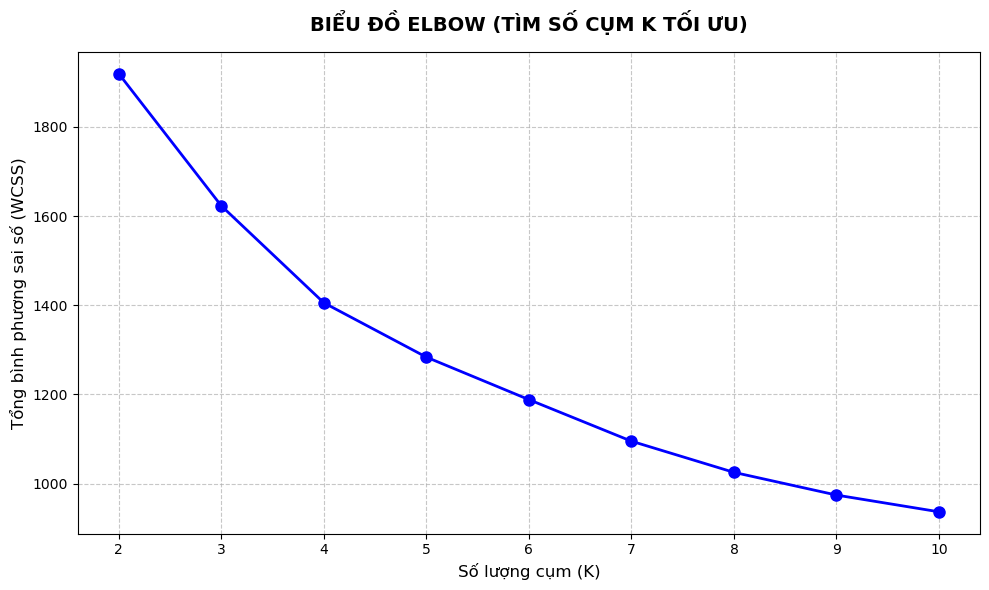

--------------------------------------------------------------------------------
✅ ĐÃ VẼ XONG BIỂU ĐỒ ELBOW!


In [13]:
# ==============================================================================
# BƯỚC 6: TÌM K TỐI ƯU BẰNG PHƯƠNG PHÁP ELBOW (KHUỶU TAY)
# ==============================================================================
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("🔍 ĐANG QUÉT K TỪ 2 ĐẾN 10 ĐỂ VẼ BIỂU ĐỒ ELBOW...\n")

# Lấy dữ liệu đã chuẩn hóa (StandardScaler)
X = df_ml[ml_features].values

# Khởi tạo mảng lưu trữ WCSS (Tổng bình phương sai số trong nội bộ cụm)
wcss = []
K_range = range(2, 11)

# Chạy vòng lặp thử nghiệm từng giá trị K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ chính là giá trị WCSS

# Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

plt.title('BIỂU ĐỒ ELBOW (TÌM SỐ CỤM K TỐI ƯU)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('Tổng bình phương sai số (WCSS)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("-" * 80)
print("✅ ĐÃ VẼ XONG BIỂU ĐỒ ELBOW!")

Kết luận: Tại điểm $K=4$, chúng ta đã vắt kiệt được phần lớn giá trị của việc chia cụm. Nếu tiếp tục cố đấm ăn xôi chia thành 5 cụm, chi phí tính toán tăng lên nhưng sai số (WCSS) không còn giảm thêm được bao nhiêu. K=4 chính là "Điểm vàng" cân bằng giữa hiệu suất và độ phức tạp.

# 6. GÁN NHÃN CHO 4 CỤM KHÁCH HÀNG 

🚀 ĐANG THỰC THI GÁN NHÃN CHÍNH THỨC VỚI K = 4...

✅ ĐÃ GÁN NHÃN CỤM THÀNH CÔNG VÀO CỘT 'final_cluster_label' CỦA df_master!
--------------------------------------------------------------------------------
📊 ĐANG VẼ BIỂU ĐỒ SCATTER PLOT VỚI MÀU SẮC VÀ TÊN TÙY CHỈNH...


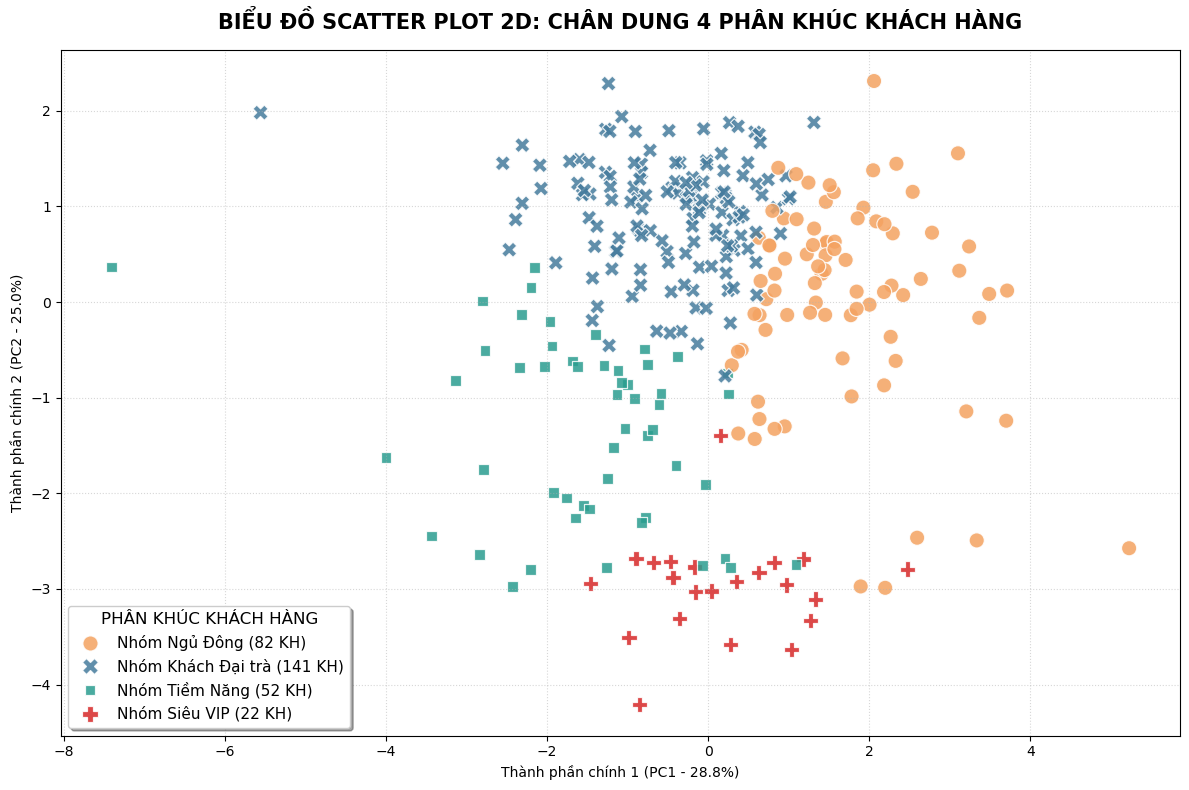

In [15]:
# ==============================================================================
# BƯỚC 6.5 & 6.6: GÁN NHÃN K=4 CHÍNH THỨC VÀ TRỰC QUAN HÓA SCATTER PLOT (CUSTOM)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

FINAL_K = 4 
print(f"🚀 ĐANG THỰC THI GÁN NHÃN CHÍNH THỨC VỚI K = {FINAL_K}...\n")

# 1. Chuẩn bị dữ liệu và Huấn luyện mô hình
X = df_ml[ml_features].values 
kmeans_final = KMeans(n_clusters=FINAL_K, init='k-means++', random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(X)

# 2. Gán nhãn vào bảng MASTER gốc
df_master['final_cluster_label'] = final_labels
print("✅ ĐÃ GÁN NHÃN CỤM THÀNH CÔNG VÀO CỘT 'final_cluster_label' CỦA df_master!")
print("-" * 80)

# 3. TRỰC QUAN HÓA SCATTER PLOT 4 CỤM (DÙNG PCA)
print("📊 ĐANG VẼ BIỂU ĐỒ SCATTER PLOT VỚI MÀU SẮC VÀ TÊN TÙY CHỈNH...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['final_cluster_label'] = final_labels.astype(str)

# ====================================================================
# 🌟 ĐIỂM ĐỘT PHÁ CỦA BẠN NẰM Ở ĐÂY: ĐẶT TÊN VÀ ĐỔI MÀU
# ====================================================================

# a) Đặt tên khai sinh cho từng cụm (Bạn hãy sửa lại tên tiếng Việt ở đây cho đúng Heatmap)
cluster_names = {
    '0': 'Nhóm Siêu VIP (22 KH)',       
    '1': 'Nhóm Khách Đại trà (141 KH)', 
    '2': 'Nhóm Tiềm Năng (52 KH)',      
    '3': 'Nhóm Ngủ Đông (82 KH)'        
}

# Tạo một cột mới chứa Tên đầy đủ để vẽ lên biểu đồ
df_pca['Tên_Phân_Khúc'] = df_pca['final_cluster_label'].map(cluster_names)

# b) Đổi màu sắc tương ứng với cái tên vừa đặt (Dùng mã màu HEX cho sang trọng)
custom_colors = {
    'Nhóm Siêu VIP (22 KH)': '#D62828',       # Đỏ rực (Quyền lực)
    'Nhóm Khách Đại trà (141 KH)': '#457B9D', # Xanh biển (Phổ thông, tin cậy)
    'Nhóm Tiềm Năng (52 KH)': '#2A9D8F',      # Xanh ngọc (Tăng trưởng)
    'Nhóm Ngủ Đông (82 KH)': '#F4A261'        # Cam/Vàng (Cảnh báo, ít hoạt động)
}
# ====================================================================

# 4. Tính phần trăm biến động
explained_variance = pca.explained_variance_ratio_

# 5. Vẽ Scatter Plot
plt.figure(figsize=(12, 8)) # Tăng chiều ngang một chút để nhét vừa cái Legend tên dài
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Tên_Phân_Khúc',     # <--- Tô màu theo cột Tên mới
    data=df_pca, 
    palette=custom_colors,   # <--- Áp dụng bảng màu Custom của bạn
    style='Tên_Phân_Khúc',   # Đổi cả hình dáng theo tên
    s=120, 
    alpha=0.85, 
    legend="full"
)

plt.title('BIỂU ĐỒ SCATTER PLOT 2D: CHÂN DUNG 4 PHÂN KHÚC KHÁCH HÀNG', fontsize=15, fontweight='bold', pad=15)
plt.xlabel(f'Thành phần chính 1 (PC1 - {explained_variance[0]*100:.1f}%)')
plt.ylabel(f'Thành phần chính 2 (PC2 - {explained_variance[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.5)

# Tùy chỉnh cái Chú thích (Legend) cho đẹp
plt.legend(title='PHÂN KHÚC KHÁCH HÀNG', title_fontsize='12', fontsize='11', loc='best', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Lưu model 

In [16]:
# ==============================================================================
# BƯỚC 7.5: LƯU MÔ HÌNH VÀ DỮ LIỆU ĐỂ TÁI SỬ DỤNG
# ==============================================================================
import joblib
import os
import pandas as pd

print("💾 ĐANG TIẾN HÀNH SAO LƯU HỆ THỐNG...")

# 1. Tạo một thư mục con tên là 'saved_models' để chứa file cho gọn gàng
os.makedirs('saved_models', exist_ok=True)

# 2. LƯU MÔ HÌNH MACHINE LEARNING (Dùng joblib)
# Lưu mô hình K-Means (Core Engine)
joblib.dump(kmeans_final, 'saved_models/kmeans_k4_model.pkl')
print("✔️ Đã lưu mô hình K-Means thành file 'kmeans_k4_model.pkl'")

# Lưu mô hình PCA (Để sau này nếu có khách hàng mới, bạn vẫn vẽ được biểu đồ 2D)
joblib.dump(pca, 'saved_models/pca_2d_model.pkl')
print("✔️ Đã lưu mô hình PCA thành file 'pca_2d_model.pkl'")

# LƯU Ý: Nếu ở Bước 3 bạn có dùng StandardScaler để scale dữ liệu, 
# hãy lưu luôn cả scaler đó (vd: joblib.dump(scaler, 'saved_models/standard_scaler.pkl'))

# 3. LƯU BẢNG DỮ LIỆU ĐÃ PHÂN CỤM (Dùng Pandas)
# Lưu thành file CSV để ngày mai mở lên là có ngay cột nhãn cụm để chạy Hệ thống NBO
df_master.to_csv('saved_models/df_master_clustered.csv', index=False)
print("✔️ Đã lưu dữ liệu Master thành file 'df_master_clustered.csv'")

print("-" * 80)
print("🎉 HOÀN TẤT CHECKPOINT! Bạn có thể tắt máy nghỉ ngơi an tâm tuyệt đối.")

💾 ĐANG TIẾN HÀNH SAO LƯU HỆ THỐNG...
✔️ Đã lưu mô hình K-Means thành file 'kmeans_k4_model.pkl'
✔️ Đã lưu mô hình PCA thành file 'pca_2d_model.pkl'
✔️ Đã lưu dữ liệu Master thành file 'df_master_clustered.csv'
--------------------------------------------------------------------------------
🎉 HOÀN TẤT CHECKPOINT! Bạn có thể tắt máy nghỉ ngơi an tâm tuyệt đối.
